<div align="center">
  <img src="https://peopledevelopmentmagazine.com/wp-content/uploads/2016/01/Human-Resources-Plan.jpg" width="500">
</div>

# **HR Attrition Prediction**
*Prof.ssa Michela Iannotta, prof. Giuseppe Ceci, Marco Sacchetti*

## **Attrition**: why workers quit?

Starting from a dataset provided by **IBM**, in this brief Colab we will explore:

1. how to import a dataset and visualize some **KPIs** and **statistics** useful for interpreting the data;
2. how to build a model useful in **HR Analytics** to explain and predict attrition.

<div align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/5/51/IBM_logo.svg" width="300">
</div>

### **1. Importing the main libreries for data analysis📂**

In [ ]:
!pip install -q hvplot
import hvplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 6.9 MB/s eta 0:00:00


In [ ]:
# processing data
import pandas as pd
import numpy as np
# visualize data
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas
# test statistic
from scipy.stats import chi2_contingency
from scipy import stats

sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

### **2) Importing the IBM dataset 🤹**

In [ ]:
file_path = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print('=== Data preview ===')
df.head() # mostra le prime righe del dataset

=== Data preview ===


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
print('=== Some dataset informations ===')
print(f'Total employees: {len(df)}')
print(f'Total features (columns): {len(df.columns)}')
print(f'Overall attrition rate: {df["Attrition"].value_counts(normalize=True)["Yes"]*100:.1f}%')
print(f'Attrited employees: {df["Attrition"].value_counts()["Yes"]}')
print(f'Retained employees: {df["Attrition"].value_counts()["No"]}')

=== Some dataset informations ===
Total employees: 1470
Total features (columns): 35
Overall attrition rate: 16.1%
Attrited employees: 237
Retained employees: 1233


🥸 Little advice\
It's good practice to **visualize the dataset** both in Python 🐍 and before importing it!

### **3) EDA: Exploratory Data Analysis 🎯**

The aim is to find **patterns** in the data through visualization.

**Univariate Analysis**

1. Histograms, box plots ➡️ distribution and central tendency  
2. Bar charts ➡️ frequency of each category  

**Bivariate Analysis**

1. Scatter plots ➡️ relationships between variables  
2. Stacked column charts ➡️ comparison of category distributions  
3. Boxplots, swarmplots ➡️ comparison of numerical variables across categories


#### 🔎 **Inspecting the dataset**


Here we take a first look at the dataset, using a sort of magnifying glass to observe its overall structure: variables, data types, the presence of missing values, descriptive statistics...

In [ ]:
df.info() #dataset overview: missing values, size, types...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Check for missing values
print('=== Missing Value Check ===')
null_count = df.isnull().sum()
print(f'Columns with missing values: {(null_count > 0).sum()}')

print('No missing values in any column!' if null_count.sum() == 0 else null_count[null_count > 0])

=== Missing Value Check ===
Columns with missing values: 0
No missing values in any column!


In [ ]:
# Variable type classification
print('\n=== Variable Type Summary ===')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()  # Numeric
cat_cols = df.select_dtypes(include='object').columns.tolist()              # Categorical
other_cols = df.select_dtypes(exclude=['int64', 'float64', 'object']).columns.tolist()

print(f'Numeric: {len(num_cols)} columns')
print(f'Categorical: {len(cat_cols)} columns')
print(f'Other type: {len(other_cols)}')

print('\n=== Unique Values in Categorical Variables ===')
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')


=== Variable Type Summary ===
Numeric: 26 columns
Categorical: 9 columns
Other type: 0

=== Unique Values in Categorical Variables ===
Attrition: ['Yes', 'No']
BusinessTravel: ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Department: ['Sales', 'Research & Development', 'Human Resources']
EducationField: ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
Gender: ['Female', 'Male']
JobRole: ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
MaritalStatus: ['Single', 'Married', 'Divorced']
Over18: ['Y']
OverTime: ['Yes', 'No']


In [ ]:
df.describe() #desc stats

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.00,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.00,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.00,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.00,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [ ]:
for column in df.columns: #search for unique values.
    print(f"{column}: Number of unique values {df[column].nunique()}")
    print("==========================================================")

Age: Number of unique values 43
Attrition: Number of unique values 2
BusinessTravel: Number of unique values 3
DailyRate: Number of unique values 886
Department: Number of unique values 3
DistanceFromHome: Number of unique values 29
Education: Number of unique values 5
EducationField: Number of unique values 6
EmployeeCount: Number of unique values 1
EmployeeNumber: Number of unique values 1470
EnvironmentSatisfaction: Number of unique values 4
Gender: Number of unique values 2
HourlyRate: Number of unique values 71
JobInvolvement: Number of unique values 4
JobLevel: Number of unique values 5
JobRole: Number of unique values 9
JobSatisfaction: Number of unique values 4
MaritalStatus: Number of unique values 3
MonthlyIncome: Number of unique values 1349
MonthlyRate: Number of unique values 1427
NumCompaniesWorked: Number of unique values 10
Over18: Number of unique values 1
OverTime: Number of unique values 2
PercentSalaryHike: Number of unique values 15
PerformanceRating: Number of uni

We notice that `EmployeeCount`, `Over18`, `StandardHours` have only one unique values and `EmployeeNumber` has 1470 unique values (it's the id number). \
This features aren't useful for us, so we are going to drop those columns.

In [ ]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis="columns", inplace=True)

In [ ]:
print('Some KPIs:')

print(f'Average Age: {df["Age"].mean():.1f} years')
print(f'Average Monthly Income: {df["MonthlyIncome"].mean():,.0f} $')
print(f'Average Tenure: {df["YearsAtCompany"].mean():.1f} years')
print(f'Average Job Satisfaction: {df["JobSatisfaction"].mean():.2f} / 4')
print(f'Average Work-Life Balance: {df["WorkLifeBalance"].mean():.2f} / 4')

Some KPIs:
Average Age: 36.9 years
Average Monthly Income: 6,503 $
Average Tenure: 7.0 years
Average Job Satisfaction: 2.73 / 4
Average Work-Life Balance: 2.76 / 4


**🥸 Technical and unuseful observation:**\
We use the command *inplace = True* in order to apply the change directly to the dataframe, without creating a new copy (with *inplace = False*).

**Alternative:**\
we could have analyzed the variables' **Coefficient of Variation (CV)**.

CV measures the relative variability of a variable by comparing its standard deviation to its mean. Higher values indicate greater dispersion of observations relative to the average.\
$$
CV = \frac{\sigma}{\mu}
$$

where:
- $\sigma$ = standard deviation  
- $\mu$ = mean  


In [ ]:
file_path = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

In [ ]:
# trasformation features into list
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist() # Numeric
cat_cols = df.select_dtypes(include='object').columns.tolist() # Categorical
other_cols = df.select_dtypes(exclude=['int64', 'float64', 'object']).columns.tolist()

In [ ]:
#Description numerical columns

desc = df[num_cols].describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(1) #add new column with cv values

print('=== Descriptive statistics summary ===')
print(desc[['mean', 'std', 'min', '50%', 'max', 'cv']].round(2))

=== Descriptive statistics summary ===
                             mean     std     min      50%      max     cv
Age                         36.92    9.14   18.00    36.00    60.00  24.70
DailyRate                  802.49  403.51  102.00   802.00  1499.00  50.30
DistanceFromHome             9.19    8.11    1.00     7.00    29.00  88.20
Education                    2.91    1.02    1.00     3.00     5.00  35.20
EmployeeCount                1.00    0.00    1.00     1.00     1.00   0.00
EmployeeNumber            1024.87  602.02    1.00  1020.50  2068.00  58.70
EnvironmentSatisfaction      2.72    1.09    1.00     3.00     4.00  40.20
HourlyRate                  65.89   20.33   30.00    66.00   100.00  30.90
JobInvolvement               2.73    0.71    1.00     3.00     4.00  26.10
JobLevel                     2.06    1.11    1.00     2.00     5.00  53.60
JobSatisfaction              2.73    1.10    1.00     3.00     4.00  40.40
MonthlyIncome             6502.93 4707.96 1009.00  4919.00 19

In [ ]:
print('Some KPIs:')

print(f'Average Age: {df["Age"].mean():.1f} years')
print(f'Average Monthly Income: {df["MonthlyIncome"].mean():,.0f} $')
print(f'Average Tenure: {df["YearsAtCompany"].mean():.1f} years')
print(f'Average Job Satisfaction: {df["JobSatisfaction"].mean():.2f} / 4')
print(f'Average Work-Life Balance: {df["WorkLifeBalance"].mean():.2f} / 4')

Some KPIs:
Average Age: 36.9 years
Average Monthly Income: 6,503 $
Average Tenure: 7.0 years
Average Job Satisfaction: 2.73 / 4
Average Work-Life Balance: 2.76 / 4


In [ ]:
#identifing highest CV variables

desc_sorted = desc.sort_values('cv', ascending=False)

print('=== Top 5 high-CV variables ===')
print(desc_sorted[['mean', 'cv']].head(5))

print('\n=== Variables excluded from analysis (CV = 0) ===')
print(desc_sorted[desc_sorted['cv'] == 0].index.tolist())

=== Top 5 high-CV variables ===
                         mean     cv
YearsSinceLastPromotion  2.19 147.30
StockOptionLevel         0.79 107.30
NumCompaniesWorked       2.69  92.80
DistanceFromHome         9.19  88.20
YearsAtCompany           7.01  87.40

=== Variables excluded from analysis (CV = 0) ===
['EmployeeCount', 'StandardHours']


👨‍💼**Descriptive statistics easy HR interpretation**



| Variable | CV | HRD Interpretation |
|---|---|---|
| YearsSinceLastPromotion | 147% | Some employees are promoted relatively quickly, while others remain without promotion for several years, suggesting potential disparities in promotion processes or career progression opportunities, which may also lead to demotivation. |
| StockOptionLevel | 107% | Most employees receive no stock options, while only a small subset benefits from higher option levels. This suggests that long-term financial incentives are concentrated among a limited group of employees, potentially reflecting disparities in compensation and retention strategies. |
| NumCompaniesWorked | 92% | Employees show highly heterogeneous career histories, suggesting diverse career trajectories and potential differences in turnover behavior. |
| MonthlyIncome | 72% | Monthly income varies substantially across employees, suggesting considerable salary dispersion that may reflect differences in job roles, seniority, and organizational hierarchy. |

**⚒️ What about Attrition** (`Attrition`)

This bar chart shows the number of employees who stayed in the company and those who left.  
Understanding the distribution of the target variable is important before building predictive models.

If the classes are highly imbalanced, additional adjustments may be required during model construction.

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#reimport dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
attrition_counts = df['Attrition'].value_counts().reset_index() #trasformazione in dataframe x evitare problemi con i frameworks
attrition_counts.columns = ['Status', 'Count']

#df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis="columns", inplace=True)

color_map = {'No': '#2ecc71', 'Yes': '#e74c3c'} #red leave, green stay
colors = [color_map[status] for status in attrition_counts['Status']]

#subplotsing
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "bar"}, {"type": "pie"}]],
    subplot_titles=("Attrition Count", "Attrition Percentage")
)

# 3. Bar Chart
fig.add_trace(
    go.Bar(
        x=attrition_counts['Status'],
        y=attrition_counts['Count'],
        text=attrition_counts['Count'],
        textposition='auto',
        marker=dict(color=colors),
        name='Count',
        showlegend=False
    ),
    row=1, col=1
)

# 4. Pie Chart
fig.add_trace(
    go.Pie(
        labels=attrition_counts['Status'],
        values=attrition_counts['Count'],
        hole=0.4,
        marker=dict(colors=[color_map['No'], color_map['Yes']]),
        name='Ratio',
        textinfo='label+percent'
    ),
    row=1, col=2
)

# 5. Final Layout
fig.update_layout(
    title_text="<b>Overall Attrition</b>",
    template='plotly_white',
    height=700,
    legend=dict(title="Legend", orientation="h", y=-0.1, x=0.5, xanchor="center")
)

fig.show()

**👨‍💼 HR thinking 💭**

1. The overall attrition rate is 16.1%, which slightly exceeds the commonly
reported industry benchmark of 10–15% (SHRM allegare fonte). This suggests that the organization may be experiencing a problematic level of turnover, as it is higher than the typical physiological turnover rate.

2. In absolute terms, 237 employees have left the company. Since replacing an employee typically costs between 50% and 200% of their annual salary, including recruitment, onboarding, training, and lost productivity, the financial impact of attrition can be significant. In this case, it is estimated to exceed $4 million (estimated loss about \$ 4M).\
From a strategic HR perspective, these findings highlight that a reactive approach based solely on replacing employees is economically inefficient. Instead, **investing in proactive retention strategies**, such as competitive compensation, career development opportunities, can significantly reduce turnover costs and enhance organizational stability.

3. High attrition may lead to a loss of organizational knowledge and experience. When employees leave, companies not only lose their skills but also the tacit knowledge they have developed over time. This can negatively affect team performance, continuity of operations and the quality of decision-making.

4. The analysis suggests that attrition should not only be monitored as an HR metric, but also managed as a critical driver of organizational performance and cost efficiency.

5. OTHER?????

🥁 **What about correlation?**

In [ ]:
file_path = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()  # Numeric
cat_cols = df.select_dtypes(include='object').columns.tolist()              # Categorical
other_cols = df.select_dtypes(exclude=['int64', 'float64', 'object']).columns.tolist()

In [ ]:
# Encode binary variables (necessary for .corr())
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTime'] = (df['OverTime'] == 'Yes').astype(int)
df['Gender'] = (df['Gender'] == 'Male').astype(int)
df['MarSingle'] = (df['MaritalStatus'] == 'Single').astype(int)

# Variables for the analysis
analysis_cols = num_cols + ['OverTime', 'Gender', 'MarSingle']

# Correlation with attrition
corr_with_attrition = (
    df[analysis_cols + ['Attrition_bin']]
    .corr()['Attrition_bin']
    .drop('Attrition_bin')
    .sort_values(key=abs, ascending=False)
)

# Top 10 variables
top10 = corr_with_attrition.head(10).reset_index()
top10.columns = ['Variable', 'Correlation']

# Colors: red = risk factor, green = protective factor
top10['Color'] = top10['Correlation'].apply(lambda x: '#e74c3c' if x > 0 else '#2ecc71')

# Reverse order for better readability
top10 = top10.iloc[::-1]

# hvplot bar chart
top10.hvplot.barh(
    x='Variable',
    y='Correlation',
    color='Color',
    height=500,
    width=800,
    title='Top 10 Variables Correlated with Attrition',
    xlabel='Correlation Coefficient',
    line_color='black'
)

:Bars   [Variable]   (Correlation,Color)

📲 **Data visualization**

🏘️ **About distance from home** (`DistanceFromHome`):

In [ ]:
df.hvplot.hist(y='DistanceFromHome', by='Attrition', title='Attrition by DistanceFromHome', ylabel='Count', subplots=False, width=800, height=500, bins=30)

:NdOverlay   [Attrition]
   :Histogram   [DistanceFromHome]   (Count)

📊🥸 **Statistical approach**

To verify whether commuting distance differs between employees who stay and those who leave the company, we compare the distributions of `DistanceFromHome` across the two groups defined by `Attrition`.

The Mann–Whitney U test is used because it does not assume normality and is appropriate for comparing two independent groups. Thorugh this test we want to...

The null hypothesis states that the distribution of `DistanceFromHome` is the same for employees who stay and those who leave. A small p-value would indicate that commuting distance differs significantly between the two groups.

In [ ]:
from scipy.stats import mannwhitneyu

stay = df[df['Attrition'] == 'No']['DistanceFromHome']
leave = df[df['Attrition'] == 'Yes']['DistanceFromHome']

u_stat, p_val = mannwhitneyu(stay, leave)

print("Mann-Whitney U:", u_stat)
print("p-value:", p_val)

Mann-Whitney U: 127995.5
p-value: 0.0023870470273627984


📊🥸 **Comment**

The Mann–Whitney test indicates a statistically significant difference between the two groups (p = 0.002). However, the graphical inspection suggests that the difference between the distributions is relatively small.



The purpose of this test is to verify whether the observed differences between the distributions are statistically significant or simply the result of random variation.\
In exploratory data analysis, it is good practice to examine both visualizations and statistical tests. Graphs help identify potential patterns, while empirical tests allow us to verify whether these patterns are statistically supported. The results should therefore be interpreted carefully by considering both graphical evidence and statistical inference.

🏘️ **About monthly income** (`MonthlyIncome`):

In [ ]:
df.hvplot.hist(y='MonthlyIncome', by='Attrition', title='Attrition by MonthlyIncome', ylabel='count', subplots=False, width=800, height=500, bins=50)

:NdOverlay   [Attrition]
   :Histogram   [MonthlyIncome]   (Count)

In [ ]:
from scipy.stats import mannwhitneyu

# Test per il Reddito
stat, p = mannwhitneyu(df[df['Attrition']=='Yes']['MonthlyIncome'],
                       df[df['Attrition']=='No']['MonthlyIncome'])

print(f'P-value: {p}') # Se p < 0.05, la differenza è significativa

P-value: 2.950830917288873e-14


In [ ]:
import numpy as np

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

# Esempio per il MonthlyIncome
group_yes = df[df['Attrition'] == 'Yes']['MonthlyIncome']
group_no = df[df['Attrition'] == 'No']['MonthlyIncome']

risultato_d = cohen_d(group_no, group_yes)
print(f"D di Cohen: {risultato_d}")

D di Cohen: 0.44001780335915686


In [ ]:
stay = df[df['Attrition'] == 'No']['MonthlyIncome']
leave = df[df['Attrition'] == 'Yes']['MonthlyIncome']

u_stat, p_val = mannwhitneyu(stay, leave)

print("Mann-Whitney U:", u_stat)
print("p-value:", p_val)

Mann-Whitney U: 191600.5
p-value: 2.950830917288873e-14


🗿 **Statistical approach**

To evaluate whether salary differs between employees who stay and those who leave the company, we compare the distributions of `MonthlyIncome` across the two groups defined by `Attrition`.

A Mann–Whitney U test indicates a statistically significant difference between the two groups (p < 0.0001), suggesting that employee income levels are associated with attrition patterns.\
The histogram also supports this result. Employees who leave the company tend to be more concentrated in the lower income ranges, while higher income levels are predominantly associated with employees who remain in the organization. Although the two distributions partially overlap, the graphical evidence suggests that lower salaries are more common among employees who experience attrition.


🐦‍🔥 **About Performance Rating** (`PerformanceRating`)

In [ ]:
file_path = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

In [ ]:
import plotly.express as px
from scipy import stats
import numpy as np

# 1. Gruppi
group_yes = df[df['Attrition'] == 'Yes']['PerformanceRating']
group_no = df[df['Attrition'] == 'No']['PerformanceRating']

# 2. Mann-Whitney U Test
stat, p_val = stats.mannwhitneyu(group_yes, group_no)

# 3. Cohen's d
def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(g1) - np.mean(g2)) / pooled_std

d_val = cohen_d(group_yes, group_no)

# 4. Grafico interattivo
fig = px.histogram(
    df,
    x='PerformanceRating',
    color='Attrition',
    barmode='group',
    title='Attrition by performance rating',
    labels={'PerformanceRating': 'Performance Rating', 'count': 'Conteggio Dipendenti'},
    color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'},
    category_orders={'PerformanceRating': [1, 2, 3, 4]}
)

fig.update_layout(
    xaxis_title='Performance Rating',
    yaxis_title='count',
    legend_title='Attrition',
    bargap=0.2
)

fig.show()

# 5. Risultati
print(f"--- RISULTATI TEST ---")
print(f"P-Value: {p_val:.4f}")
print(f"D di Cohen: {abs(d_val):.4f}")

--- RISULTATI TEST ---
P-Value: 0.9119
D di Cohen: 0.0079


`PerformanceRating`

To evaluate whether performance ratings differ between employees who stay and those who leave the company, we compare the distributions of `PerformanceRating` across the two groups defined by Attrition.

The Mann–Whitney U test returns a p-value of 0.91, indicating **no statistically significant difference** between the two groups. This result suggests that performance ratings are not associated with attrition patterns.

The Cohen's d value of 0.008 confirms this finding: the effect size is negligible, meaning the distributions of performance ratings between the two groups are virtually identical.

The histogram further supports this conclusion, showing that the proportion of employees who leave is consistent across all performance rating levels, with no visible concentration in any particular rating category.

In summary, `PerformanceRating` does not appear to be a meaningful predictor of attrition in this dataset. Employees who leave and those who stay exhibit nearly identical performance rating distributions, suggesting that other variables are far more relevant in explaining turnover behavior.



🔍 **Attrition by job role**

In [ ]:
# Define shared variables used across all analysis steps
total = len(df)
attrition_yes  = df['Attrition'].value_counts()[1]
attrition_no = df['Attrition'].value_counts()[0]
attrition_rate = df['Attrition'].value_counts(normalize=True)[1] * 100

print(f'Total: {total}, Attrited: {attrition_yes}, Retained: {attrition_no}, Rate: {attrition_rate:.1f}%')
print('Common variables set successfully')

Total: 1470, Attrited: 237, Retained: 1233, Rate: 16.1%
Common variables set successfully


/tmp/ipykernel_1083/722972130.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  attrition_yes  = df['Attrition'].value_counts()[1]
/tmp/ipykernel_1083/722972130.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  attrition_no = df['Attrition'].value_counts()[0]
/tmp/ipykernel_1083/722972130.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  attrition_rate = df['Attrition'].value_counts(normalize=True)[1] * 100


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Convert Attrition to numeric (1 for Yes, 0 for No)
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Calculate overall average
overall_avg = df['Attrition_Num'].mean() * 100

# Calculate attrition rate per Job Role
jobrole_attr = df.groupby('JobRole')['Attrition_Num'].mean() * 100
jobrole_attr = jobrole_attr.reset_index().sort_values('Attrition_Num', ascending=True)
jobrole_attr.columns = ['JobRole', 'AttritionRate']

# crea plotting interattivo
fig = px.bar(
    jobrole_attr,
    x='AttritionRate',
    y='JobRole',
    orientation='h',
    title='<b>Attrition Rate by Job Role</b><br><sup>Risk Threshold: 20%</sup>',
    labels={'AttritionRate': 'Attrition Rate (%)', 'JobRole': 'Job Role'},
    text_auto='.1f', # Shows percentage on the bars
    color='AttritionRate',
    # Color map: Green below 20%, Red above 20%
    color_continuous_scale=[[0, '#2ECC71'], [0.2, '#2ECC71'], [0.201, '#e74c3c'], [1, '#e74c3c']]
)

#linea verticale x la media
fig.add_vline(
    x=overall_avg,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Company Avg: {overall_avg:.1f}%",
    annotation_position="bottom right"
)

# Layout Improvements
fig.update_layout(
    showlegend=False,
    coloraxis_showscale=True, # False to hide the side color bar
    height=500,
    margin=dict(l=50, r=50, t=80, b=50),
    template='plotly_white'
)

fig.show()

🔎 **HR insights on role & attrition**

- **High-risk roles:**
  - Human Resources  
  - Laboratory Technician  
  - Sales Representative & Executive

- **Severity of the issue**
  - Average attrition rate of high-risk roles: **28.9%**
  - This is approximately **1.8× higher** than the overall company average (16.1%)
  - Indicates a **concentration of turnover risk in specific job families**

- **Analytical contribution**
  - Attrition is **not evenly distributed**, but clustered in specific roles  
  - This suggests the presence of **role-specific structural drivers of turnover**   

- **Managerial implications**
  - Prioritize **role-specific retention strategies** rather than general interventions  
  - Examples of intervent????

 🔍 **Attrition by HR Variables**

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Pre-elaborazione dati
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
overall_avg = df['Attrition_Num'].mean() * 100

hrd_vars = [
    ('JobSatisfaction', 'Job Satisfaction'),
    ('WorkLifeBalance', 'Work-Life Balance'),
    ('EnvironmentSatisfaction', 'Environment Satisfaction'),
    ('JobInvolvement', 'Job Involvement')
]

# 2. Creazione Subplots (2 righe, 2 colonne)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[v[1] for v in hrd_vars],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# 3. Ciclo per popolare i grafici
for i, (col, title) in enumerate(hrd_vars):
    # Calcolo tassi
    rates = df.groupby(col)['Attrition_Num'].mean() * 100

    # Definizione colori (Rosso > media, Blu < media)
    colors = ['#E24B4A' if r > overall_avg else '#2ECC71' for r in rates]

    row = (i // 2) + 1
    col_idx = (i % 2) + 1

    # Aggiunta barre
    fig.add_trace(
        go.Bar(
            x=rates.index,
            y=rates.values,
            marker_color=colors,
            text=rates.values.round(1),
            textposition='auto',
            name=title,
            hovertemplate="Score: %{x}<br>Rate: %{y:.1f}%<extra></extra>"
        ),
        row=row, col=col_idx
    )

    # Aggiunta linea media aziendale per ogni subplot
    fig.add_shape(
        type="line", x0=0.5, x1=4.5, y0=overall_avg, y1=overall_avg,
        line=dict(color="Gray", width=2, dash="dash"),
        row=row, col=col_idx
    )

# 4. Layout finale
fig.update_layout(
    title_text="<b>Attrition Rate by Key HRD Variables</b><br><sup>Red bars indicate rates above company average</sup>",
    height=800,
    showlegend=False,
    template='plotly_white'
)

# Aggiornamento assi per uniformità (scala 1-4)
fig.update_xaxes(tickvals=[1, 2, 3, 4], title_text="Score")
fig.update_yaxes(title_text="Attrition Rate (%)")

fig.show()

👥 **HR interpretation?**

- **Job Satisfaction**: Employees with low job satisfaction show an attrition rate of 22.8%, compared to 11.3% among those with high satisfaction, resulting in a 2.0× gap. This suggests that dissatisfaction with job roles or tasks may increase the likelihood of leaving the organization. From an HRD perspective, job crafting workshops could help employees reshape aspects of their work to improve motivation and alignment with personal strengths.
- **Work–Life Balance**: Employees reporting low work–life balance have an attrition rate of 31.2%, compared to 17.6% among those with high balance, corresponding to a 1.8× gap. This pattern indicates that difficulties in balancing professional and personal responsibilities may contribute to turnover intentions. Burnout prevention training and flexible work policies could help organizations mitigate this risk.
- **Environment Satisfaction**: Employees with low satisfaction with the work environment exhibit an attrition rate of 25.4%, while those with high satisfaction show a rate of 13.5%, producing a 1.9× gap. This suggests that organizational climate and workplace conditions play a relevant role in employee retention. Organizational culture and climate improvement programs could therefore be beneficial.
- **Job Involvement**: This variable shows the largest gap, with an attrition rate of 33.7% among employees with low job involvement compared to 9.0% among those with high involvement, resulting in a 3.7× difference. This finding highlights employee engagement as a key factor in retention. Engagement coaching and job redesign initiatives may help strengthen employees’ psychological connection with their work.
- **Overall HRD implication**: All four variables are closely related to employee engagement, satisfaction, and well-being, and are therefore directly addressable through HR development interventions, training programs, and supportive organizational policies aimed at improving the employee experience and reducing turnover risk.

In [ ]:
import plotly.express as px

# prep. dei dati: contiamo le occorrenze per ogni combinazione
# Questo passaggio serve a Plotly per costruire le etichette corrette
df_grouped = df.groupby(['OverTime', 'Attrition']).size().reset_index(name='Count')

# grafico a bare
fig = px.bar(
    df_grouped,
    x="OverTime",
    y="Count",
    color="Attrition",
    text="Count",  # Mostra il numero sopra la barra
    barmode="group", # Barre affiancate (non impilate)
    title="Attrition by Overtime",
    # Personalizzazione colori: Yes -> Rosso (Crimson), No -> Verde (ForestGreen)
    color_discrete_map={'Yes': '#E24B4A', 'No': '#2ECC71'},
    labels={'Count': 'employees number', 'OverTime': 'overtime'}
)

# layout
fig.update_layout(
    xaxis_title="OverTime",
    yaxis_title="count",
    legend_title="Attrition",
    hovermode="x unified" # Mostra entrambi i valori al passaggio del mouse
)

# Visualizza il grafico
fig.show()

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Load data
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. Create Contingency Table (Observed Frequencies)
# Cross-tabulating OverTime (rows) and Attrition (columns)
contingency_table = pd.crosstab(df['OverTime'], df['Attrition'])

# 3. Chi-Square Test
# Returns: chi2 stat, p-value, degrees of freedom, expected frequencies
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# 4. Odds Ratio (OR) Calculation
# Measures how many times more likely Attrition is for those working OverTime
a = contingency_table.loc['Yes', 'Yes'] # Overtime Yes, Attrition Yes
b = contingency_table.loc['Yes', 'No']  # Overtime Yes, Attrition No
c = contingency_table.loc['No', 'Yes']  # Overtime No, Attrition Yes
d = contingency_table.loc['No', 'No']   # Overtime No, Attrition No

odds_ratio = (a / b) / (c / d)

# 5. Percentage calculation for the report
pct_table = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

print("=== OVERTIME STATISTICAL ANALYSIS ===")
print(f"P-Value: {p_value:.22f}")
print(f"Odds Ratio: {odds_ratio:.4f}")

print("\n=== ATTRITION RATES (ATTRITION = YES) ===")
print(f"Employees working Overtime:    {pct_table.loc['Yes', 'Yes']:.2f}%")
print(f"Employees NOT working Overtime: {pct_table.loc['No', 'Yes']:.2f}%")

=== OVERTIME STATISTICAL ANALYSIS ===
P-Value: 0.0000000000000000000082
Odds Ratio: 3.7712

=== ATTRITION RATES (ATTRITION = YES) ===
Employees working Overtime:    30.53%
Employees NOT working Overtime: 10.44%


🧲 **How HR should interpret this result?**

The statistical analysis reveals a critical relationship between workload and employee retention. For the HR department, these results provide a clear roadmap for intervention:


1. The **Odds Ratio of 3.77** indicates that working overtime is not just a minor inconvenience but a primary driver of turnover. Employees working extra hours are nearly **four times more likely to leave**. The **p-value** confirms that this isn't a random occurrence; it is a systematic issue. HR should interpret frequent overtime as a leading indicator of burnout and declining work-life balance.

2. While overtime might solve immediate operational needs, it creates a long-term "talent drain."
    * **Key Metric:** The attrition rate jumps from **10.44%** to **30.53%** when overtime is introduced.
    * **HR Action:** Management must weigh the cost of hiring and training new staff against the perceived savings of stretching the current workforce.

3. HR ideas:
 * **Proactive Monitoring:** HR should implement automated alerts for managers when an employee exceeds a specific threshold of overtime hours.
 * **Stay Interviews:** HR should prioritize "Stay Interviews" with high-performing employees in the "Overtime: Yes" category to address dissatisfaction before they reach the decision to quit.
 * HR should advocate for a more balanced resource allocation. Reducing systemic overtime could potentially reduce the overall attrition rate by up to **20 percentage points** for that specific cohort, significantly lowering recruitment costs and preserving institutional knowledge.

**any comment, thought, reflection, idea?** 🧑‍🎓💭🔍

**Fin qui ok**

### **Predicting employee attrition using some models** 🗿🥸🔍

The algorithms work only with **numerical variables** so my dataframe need to be converted into such type!\
So we need to **encode** the categorical var.\
Let's re-update the orginal dataframe (we want the cells to be indipendent)!

In [ ]:
import pandas as pd

file_path = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

In [ ]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'PerformanceRating'], axis="columns", inplace=True) #elimina le variabili poco utili x risparmiare potere di calcolo

Let's remember that we removed some variables from the dataset because they contained limited information or showed very little variability, making them less useful for the analysis.\
`EmployeeCount`, `Over18`, `StandardHours` have only one unique values and `EmployeeNumber` has 1470 unique values (it's the id number).

**📊📈 About the metrics:**

The cost of failing to identify employees who are about to leave is typically much higher than the cost of incorrectly flagging employees who would have stayed. For this reason, **Recall** becomes a more relevant evaluation metric than accuracy, since the objective is to detect as many at-risk employees as possible.

$$
Recall = \frac{TP}{TP + FN}
$$

where:

- $TP$ = **True Positives** (employees who will leave and are correctly predicted by the model);
- $FN$ = **False Negatives** (employees who will leave but are not identified by the model).

While recall focuses on capturing as many at-risk employees as possible, **Precision** evaluates the reliability of these predictions. In other words, it measures the proportion of correctly identified leavers among all employees flagged as at risk, thus reflecting the extent to which the model avoids false alarms.

$$
Precision = \frac{TP}{TP + FP}
$$

where:

- $TP$ = **True Positives** (employees who will leave and are correctly predicted);
- $FP$ = **False Positives** (employees predicted to leave but who would actually stay).


*Da inserire tipo fonti x costi di processi*


The **F1 score** is the harmonic mean of precision and recall, and it is particularly useful when we want to balance the trade-off between identifying as many at-risk employees as possible (recall) and avoiding too many false alarms (precision).

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

In [ ]:
# importa livrerie machine learning
from sklearn.preprocessing import LabelEncoder # Encode categorical → numeric
from sklearn.model_selection import train_test_split  # Train/test split
from sklearn.linear_model import LogisticRegression  # Interpretable model
from sklearn.ensemble import RandomForestClassifier # Predictive model
from sklearn.metrics import classification_report, roc_auc_score  # Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Step 1. Preprocessing
df_new = df.copy()

# Encode target: Yes=1, No=0
df_new['Attrition'] = (df_new['Attrition'] == 'Yes').astype(int)


# Encode categorical variables
le = LabelEncoder()
for col in df_new.select_dtypes(include='object').columns:
    df_new[col] = le.fit_transform(df_new[col])

# Split features (X) and target (y)
X = df_new.drop(columns='Attrition') # 30 features after encoding
y = df_new['Attrition'] # Binary target: 0 or 1

# splitting 80, 20
# stratify=y: maintains 16.1% attrition ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('splitting successfully done!')

splitting successfully done!


**🔍 Let's verify the Attrition is consistently distributed across both the training and test sets to ensure the split is representative of the original data 🔍**

In [ ]:
# Verifica la percentuale di Attrition nel Training Set

print("Attrition in training set:")
print(y_train.value_counts(normalize=True))

# Verifica la percentuale di Attrition nel Test Set
print("Attrition in test set:")
print(y_test.value_counts(normalize=True))

Attrition in training set:
Attrition
0   0.84
1   0.16
Name: proportion, dtype: float64
Attrition in test set:
Attrition
0   0.84
1   0.16
Name: proportion, dtype: float64


1️⃣ **Logistic regression** (interpretability goal)

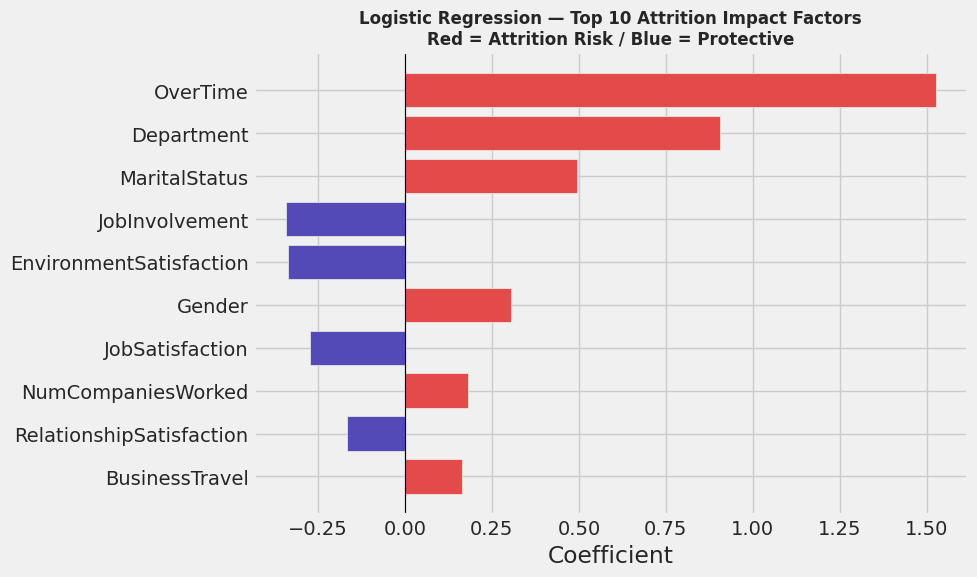

In [ ]:
# class_weight='balanced': corrects for 1:5 class imbalance
# max_iter=1000: allow sufficient iterations for convergence


#lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Coefficient visualization: positive = attrition risk factor, negative = protective factor
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef'   : lr.coef_[0]
}).sort_values('coef', key=abs, ascending=False).head(10)

colors = ['#E24B4A' if v > 0 else '#534AB7' for v in coef_df['coef']]
plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'][::-1], coef_df['coef'][::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Top 10 Attrition Impact Factors\nRed = Attrition Risk / Blue = Protective',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

In [ ]:
# Inizializza lo scaler
scaler = StandardScaler()

# Applica lo scaler (si impara dal train e si applica al test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ora ri-addestra il modello usando i dati scalati
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

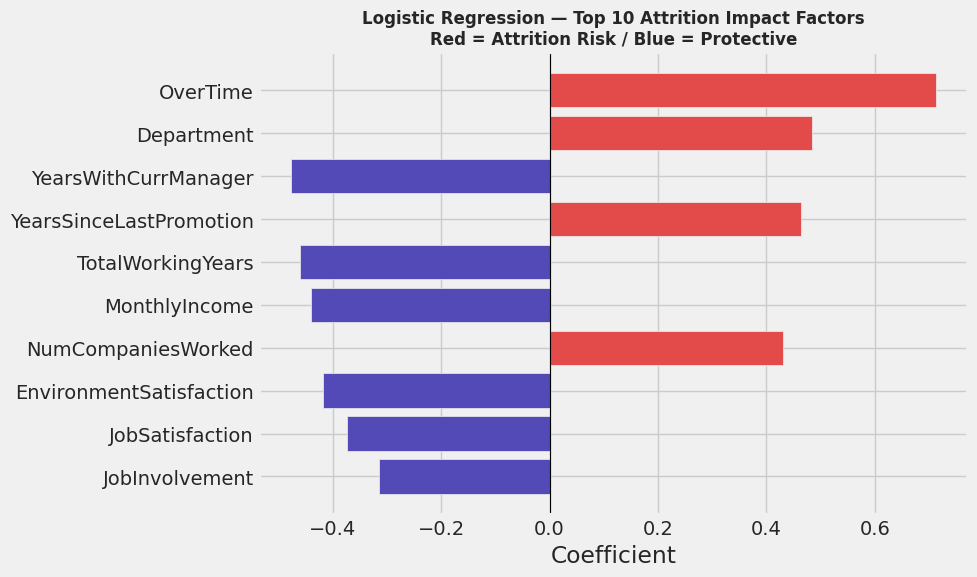

In [ ]:
# class_weight='balanced': corrects for 1:5 class imbalance
# max_iter=1000: allow sufficient iterations for convergence


#lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Coefficient visualization: positive = attrition risk factor, negative = protective factor
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef'   : lr.coef_[0]
}).sort_values('coef', key=abs, ascending=False).head(10)

colors = ['#E24B4A' if v > 0 else '#534AB7' for v in coef_df['coef']]
plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'][::-1], coef_df['coef'][::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Top 10 Attrition Impact Factors\nRed = Attrition Risk / Blue = Protective',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

📊 **Interpretation of Attrition Impact Factors**\
The horizontal bar chart visualizes the Logistic Regression coefficients, representing the weight each feature has on the probability of an employee leaving the company.

  * **Attrition Risk Factors (Red Bars)**: Positive coefficients indicate variables that increase the likelihood of turnover. `OverTime` is the dominant predictor, followed by `Department` and `MaritalStatus`. However,  `MaritalStatus` is not under HR control.

  * **Protective Factors (Blue Bars)**: Negative coefficients highlight features that help retain talent. High levels of `JobInvolvement` and `EnvironmentSatisfaction` act as the strongest "anchors," significantly offsetting the risk of resignation.

  * **Magnitude of Impact**: The length of the bars (absolute value) indicates the strength of the influence. Factors like `BusinessTravels` and `RelationshipSatisfaction`, while relevant, have a much smaller impact on the final decision compared to the top drivers.

  * **Key Takeaway**: To reduce attrition, HR interventions should prioritize the mitigation of `OverTime` and focus on enhancing `JobInvolvement`, as these variables exert the most significant mathematical pressure on the model's predictions. Variables like `MaritalStatus` or `NumCompaniesWorked` show a mathematical correlation with attrition, they represent personal background data that is non-actionable. HR interventions should instead focus on "controllable" drivers.

🚨 **Focus: Impact of** `OverTime` **on Attrition**

The model identifies `OverTime` as the most critical risk factor.

* **Risk Multiplier:** `OverTime` acts as a powerful catalyst for turnover. With a coefficient of approximately **1.5**, the **Odds Ratio** ($e^{1.5} \approx 4.48$) indicates that employees working overtime are nearly **4.5 times more likely** to leave the company compared to those who do not, holding all other factors constant.
* **Strategic Leverage:** Reducing overtime is the most effective intervention available. By addressing workload balance, the company has the highest probability of retaining the **74% of at-risk employees** currently flagged by the model's recall.

=== Classification Report ===

              precision    recall  f1-score   support

           0       0.94      0.75      0.83       247
           1       0.36      0.74      0.49        47

    accuracy                           0.75       294
   macro avg       0.65      0.75      0.66       294
weighted avg       0.85      0.75      0.78       294

=== Confusion Matrix ===



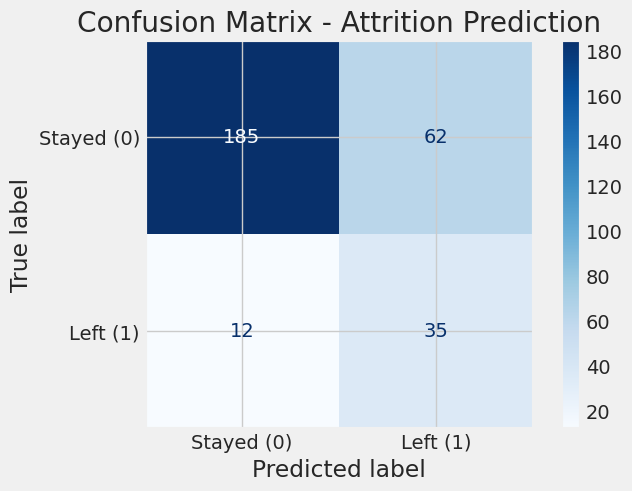

In [ ]:
# 1. Stampa il report testuale
print("=== Classification Report ===\n")
print(classification_report(y_test, y_pred_lr))

# 2. Visualizza la Confusion Matrix (Grafica)
print("=== Confusion Matrix ===\n")
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Left (1)'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Attrition Prediction')
plt.show()

* **High Recall (74%)**: The model successfully identifies 3 out of 4 employees who are actually at risk of leaving. From a business perspective, this is a major win as it allows HR to capture the vast majority of potential resignations before they happen.

* **Precision (36%)**: While there are "false alarms," this is a strategic trade-off. In talent retention, the cost of an unnecessary "stay interview" is significantly lower than the cost of losing a key employee unexpectedly.

* **Confusion Matrix Insight**: Out of 47 actual resignations, the model correctly flagged 35. The 62 "False Positives" represent employees who share similar risk profiles with those who left, making them a secondary group for proactive engagement.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

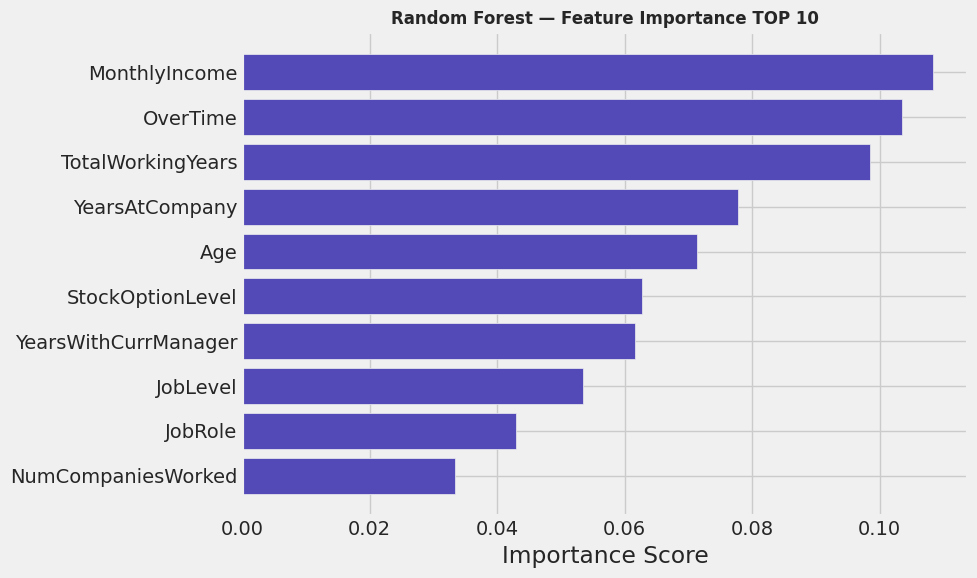

In [ ]:
# Step 3. Random Forest — Predictive Model
# n_estimators=100: ensemble of 100 decision trees
# class_weight='balanced': handles class imbalance

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth = 4,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Feature importance: each variable's contribution to predictions
fi_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='#534AB7')
plt.title('Random Forest — Feature Importance TOP 10', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#print(f'Top 3 Predictive Variables: {list(fi_df["feature"].head(3))}')

--- Classification Report RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       247
           1       0.43      0.57      0.49        47

    accuracy                           0.81       294
   macro avg       0.67      0.71      0.69       294
weighted avg       0.84      0.81      0.82       294



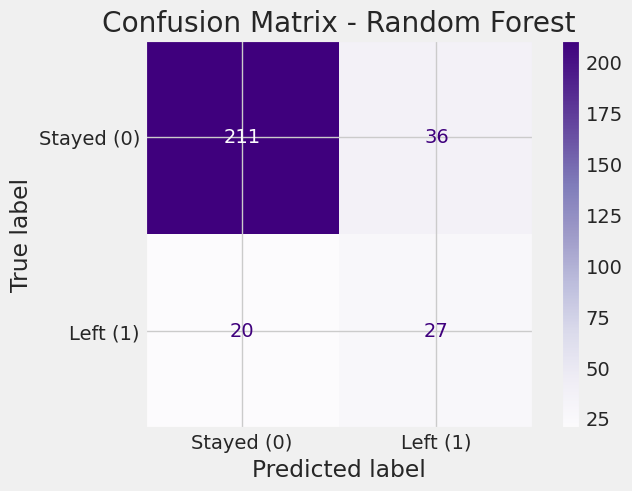

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Stampa il report testuale
print("--- Classification Report RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

# 2. Visualizza la Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Stayed (0)', 'Left (1)'])
disp_rf.plot(cmap='Purples') # Uso il viola per distinguerlo dal blu della logistica
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [ ]:
# Step 4. Model Performance Comparison
# Recall    = of all actual attrition cases, how many did the model catch?
# Precision = of all predicted attrition cases, how many were actually attrition?
# AUC       = overall discrimination ability (0.5 = random, 1.0 = perfect)

print('=' * 60)
print('  MODEL PERFORMANCE COMPARISON')
print('=' * 60)

for name, y_pred in [('Logistic Regression', y_pred_lr),
                      ('Random Forest',       y_pred_rf)]:
    auc       = roc_auc_score(y_test, y_pred)
    report    = classification_report(y_test, y_pred, output_dict=True)
    recall    = report['1']['recall']
    precision = report['1']['precision']

    print(f'\n[{name}]')
    print(f'  AUC       : {auc:.3f}')
    print(f'  Recall    : {recall:.3f}  ← How many at-risk employees were detected? (Key HRD metric)')
    print(f'  Precision : {precision:.3f}')

  MODEL PERFORMANCE COMPARISON

[Logistic Regression]
  AUC       : 0.749
  Recall    : 0.745  ← How many at-risk employees were detected? (Key HRD metric)
  Precision : 0.365

[Random Forest]
  AUC       : 0.714
  Recall    : 0.574  ← How many at-risk employees were detected? (Key HRD metric)
  Precision : 0.429


📊 **Model Performance Comparison: HR Attrition Analytics**

| Metric | **Logistic Regression** (Optimized) | **Random Forest** (max_depth=4) | Strategic Winner |
| :--- | :---: | :---: | :--- |
| **AUC (Overall Quality)** | **0.749** | 0.714 | **Logistic Regression** |
| **Recall (Detection Rate)** | **74.5%** | 57.4% | **Logistic Regression** |
| **Precision (Alert Accuracy)** | 36.5% | **42.9%** | **Random Forest** |
| **F1-Score (Balance)** | 0.49 | **0.49** | **Tie** |
| **HRD Suitability** | ✅ **High** (Capture most risks) | ⚠️ **Moderate** (Too many blind spots) | **Logistic Regression** |

---

💡 **Executive Interpretation**

1. **Logistic Regression:** This model prioritizes **coverage of risk**. By achieving a higher recall (74.5%), it enables the organization to detect a larger share of employees who are likely to leave. This makes it particularly suitable in contexts where the primary concern is to reduce the likelihood of unanticipated turnover, even at the cost of activating some unnecessary interventions.
   * *Outcome:* 7.5 out of 10 at-risk employees are identified. Very good!!

2. **Random Forest:** This model emphasizes **selectivity in intervention**. With higher precision (42.9%), it provides more reliable signals when flagging employees as at risk, but at the expense of overlooking a substantial portion of potential leavers.

🦾 **Final Recommendation**

Rather than viewing the two models as substitutes, they can be interpreted as **complementary tools** supporting different HR decision logics. Logistic Regression is more suitable for **broad risk detection and early warning systems**, while Random Forest can be leveraged for **more targeted and reliable interventions** where reducing false positives is critical.

A combined use of both models may therefore enable a more nuanced retention strategy, balancing **coverage** (recall) and **precision** depending on the specific HR objective and available resources.